In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ============================================================
# 1. LOAD DATASET
# ============================================================
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

PERBANDINGAN MODEL

Decision Tree
------------------------------------------------------------
Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
[[40  3]
 [ 3 68]]

Random Forest
------------------------------------------------------------
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
[[40  3]
 [ 1 70]]

Gradient Boosting


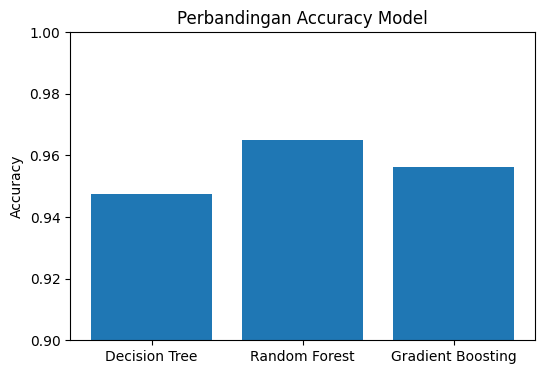

In [3]:
# ============================================================
# 2. BANDINKAN DT vs RF vs GB
# ============================================================
print("=" * 60)
print("PERBANDINGAN MODEL")
print("=" * 60)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print(f"\n{name}")
    print("-" * 60)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, pred, target_names=data.target_names))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

# ============================================================
# 3. VISUALISASI PERBANDINGAN ACCURACY
# ============================================================
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Perbandingan Accuracy Model")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()


TOP 10 FEATURE IMPORTANCE - RANDOM FOREST
 1. worst area                     importance: 0.1539
 2. worst concave points           importance: 0.1447
 3. mean concave points            importance: 0.1062
 4. worst radius                   importance: 0.0780
 5. mean concavity                 importance: 0.0680
 6. worst perimeter                importance: 0.0671
 7. mean perimeter                 importance: 0.0533
 8. mean radius                    importance: 0.0487
 9. mean area                      importance: 0.0476
10. worst concavity                importance: 0.0318


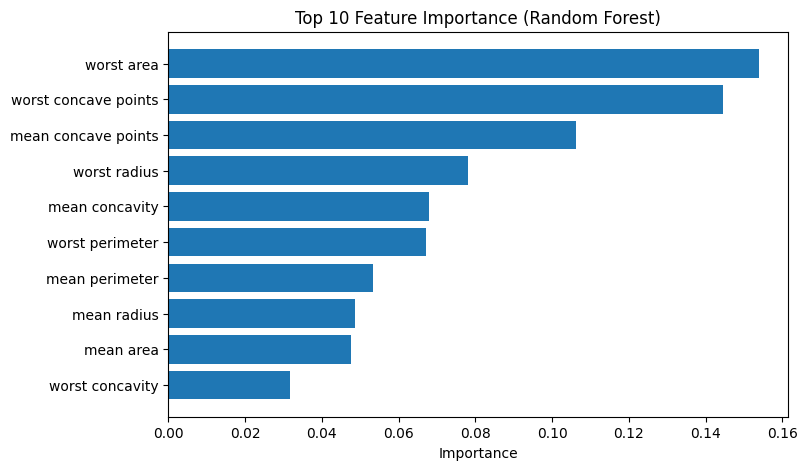

In [4]:
# ============================================================
# 4. TOP 10 FEATURE IMPORTANCE (Random Forest)
# ============================================================
print("\n" + "=" * 60)
print("TOP 10 FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 60)

rf = models["Random Forest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

top_features = []
top_values = []

for rank, idx in enumerate(indices, 1):
    fname = data.feature_names[idx]
    val = importances[idx]
    top_features.append(fname)
    top_values.append(val)
    print(f"{rank:2d}. {fname:30s} importance: {val:.4f}")

# Visualisasi Feature Importance
plt.figure(figsize=(8,5))
plt.barh(top_features[::-1], top_values[::-1])
plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()



PENGARUH n_estimators
n_estimators= 10 → accuracy: 0.9561
n_estimators= 50 → accuracy: 0.9649
n_estimators=100 → accuracy: 0.9649
n_estimators=200 → accuracy: 0.9649
n_estimators=500 → accuracy: 0.9649


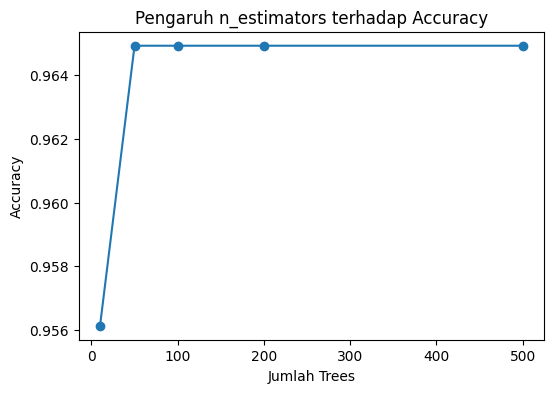

In [5]:
# ============================================================
# 5. PENGARUH n_estimators
# ============================================================
print("\n" + "=" * 60)
print("PENGARUH n_estimators")
print("=" * 60)

n_values = [10, 50, 100, 200, 500]
acc_list = []

for n in n_values:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_n.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf_n.predict(X_test))
    acc_list.append(acc)
    print(f"n_estimators={n:>3d} → accuracy: {acc:.4f}")

# Visualisasi pengaruh n_estimators
plt.figure(figsize=(6,4))
plt.plot(n_values, acc_list, marker='o')
plt.title("Pengaruh n_estimators terhadap Accuracy")
plt.xlabel("Jumlah Trees")
plt.ylabel("Accuracy")
plt.show()


In [6]:
# ============================================================
# 6. BONUS: ENSEMBLE REGRESSION
# ============================================================
print("\n" + "=" * 60)
print("BONUS: ENSEMBLE REGRESSION")
print("=" * 60)

from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

db = load_diabetes()
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    db.data, db.target, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)
pred_r = reg.predict(X_test_r)

print("RMSE:", round(root_mean_squared_error(y_test_r, pred_r), 3))
print("R2  :", round(r2_score(y_test_r, pred_r), 3))

print("\n✅ Pertemuan 06 selesai.")


BONUS: ENSEMBLE REGRESSION
RMSE: 54.332
R2  : 0.443

✅ Pertemuan 06 selesai.
